In [56]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection
import stim

import os 

while 'honeycomb.py' not in os.listdir():
    os.chdir("..")

from honeycomb import CSSHoneycomb

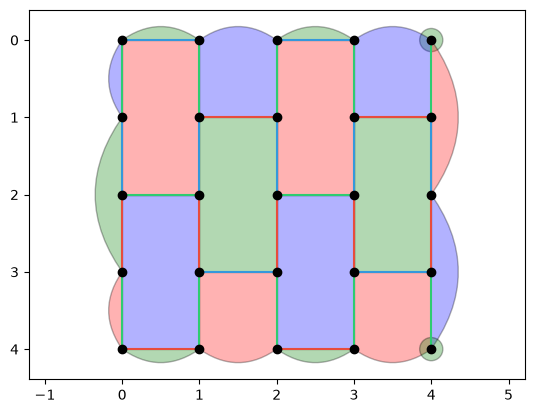

In [57]:
honey = CSSHoneycomb(5, 5)
honey.plot_surface()

In [58]:
plaquettes = honey.plaquettes
p1 = [p for p in plaquettes if len(p) == 1]
print(p1)

[BoundaryPlaquette(2), BoundaryPlaquette(20)]


# data qubits
QUBIT_COORDS(0,0) 0
QUBIT_COORDS(1,0) 1
QUBIT_COORDS(2,0) 2
QUBIT_COORDS(3,0) 3
QUBIT_COORDS(4,0) 4
QUBIT_COORDS(0,1) 5
QUBIT_COORDS(1,1) 6
QUBIT_COORDS(2,1) 7
QUBIT_COORDS(3,1) 8
QUBIT_COORDS(4,1) 9
QUBIT_COORDS(0,2) 10
QUBIT_COORDS(1,2) 11
QUBIT_COORDS(2,2) 12
QUBIT_COORDS(3,2) 13
QUBIT_COORDS(4,2) 14
QUBIT_COORDS(0,3) 15
QUBIT_COORDS(1,3) 16
QUBIT_COORDS(2,3) 17
QUBIT_COORDS(3,3) 18
QUBIT_COORDS(4,3) 19
QUBIT_COORDS(0,4) 20
QUBIT_COORDS(1,4) 21
QUBIT_COORDS(2,4) 22
QUBIT_COORDS(3,4) 23
QUBIT_COORDS(4,4) 24
# ancilla qubits
QUBIT_COORDS(0.5,0.0) 25
QUBIT_COORDS(2.5,0.0) 26
QUBIT_COORDS(0.0,0.5) 27
QUBIT_COORDS(1.0,0.5) 28
QUBIT_COORDS(1.5,1.0) 29
QUBIT_COORDS(2.0,0.5) 30
QUBIT_COORDS(3.0,0.5) 31
QUBIT_COORDS(3.5,1.0) 32
QUBIT_COORDS(4.0,0.5) 33
QUBIT_COORDS(0.0,1.5) 34
QUBIT_COORDS(0.5,2.0) 35
QUBIT_COORDS(1.0,1.5) 36
QUBIT_COORDS(2.0,1.5) 37
QUBIT_COORDS(2.5,2.0) 38
QUBIT_COORDS(3.0,1.5) 39
QUBIT_COORDS(4.0,1.5) 40
QUBIT_COORDS(0.0,2.5) 41
QUBIT_COORDS(1.0,2.5) 42
QUBI

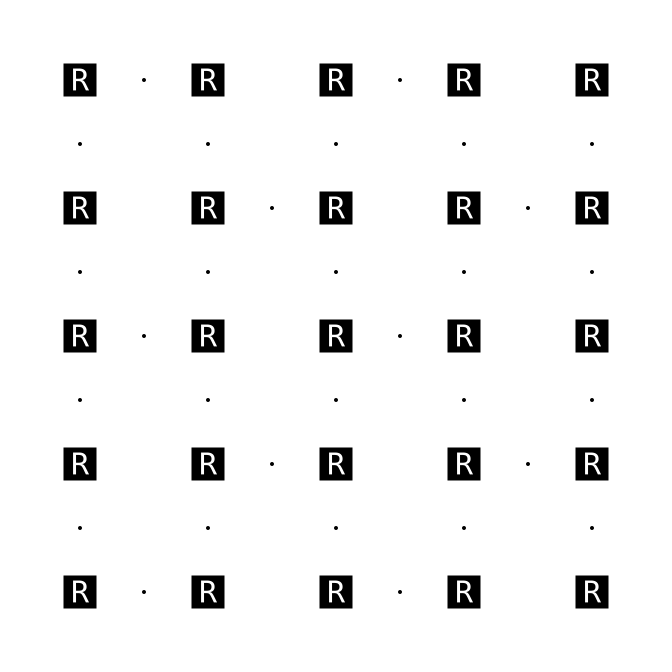

In [59]:
string = honey.initialise_circuit(coordinates='square')
string += honey.prepare_qubits()
print(string)
circuit = stim.Circuit(string)
circuit.diagram("detslice-with-ops-svg")

In [60]:
# TODO do we use letters or words?
COLOUR_MAP = {
    'r' : 'red',
    'g' : 'green',
    'b' : 'blue'
}

def measurement_cycle(honey: CSSHoneycomb, cycle=["rZ", "gX", "bZ", "rX", "gZ", "bX"]):
    """
    measure our stabilizers
    """

    string = ""
    for m in cycle:
        colour = COLOUR_MAP[m[0]]
        flavour = m[1]

        string += f"#{colour}{flavour}\n"
        string += honey.measure_edges(colour, flavour) + "\n"
        string += "tick\n"
    
    return string

print(measurement_cycle(honey, ['rXX', 'gZZ']))

#redX
# prepare ancillas in X basis
R 29 32 41 42 44 45 47 49 52 
TICK
H 29 32 41 42 44 45 47 49 52 
TICK
# fold stabilizers
CNOT 6 29 8 32 10 41 11 42 12 44 13 45 14 47 20 49 22 52 
TICK
CNOT 7 29 9 32 15 41 16 42 17 44 18 45 19 47 21 49 23 52 
TICK
# rotate ancillas back to Z basis
H 29 32 41 42 44 45 47 49 52 
TICK
M 29 32 41 42 44 45 47 49 52 
tick
#greenZ
# prepare ancillas in Z basis
R 27 28 30 31 33 35 38 48 50 51 53 54 
TICK
# fold stabilizers
CNOT 27 0 28 1 30 2 31 3 33 4 35 10 38 12 48 15 50 16 51 17 53 18 54 19 
TICK
CNOT 27 5 28 6 30 7 31 8 33 9 35 11 38 13 48 20 50 21 51 22 53 23 54 24 
TICK
M 27 28 30 31 33 35 38 48 50 51 53 54 
tick



A full cycle looks like:

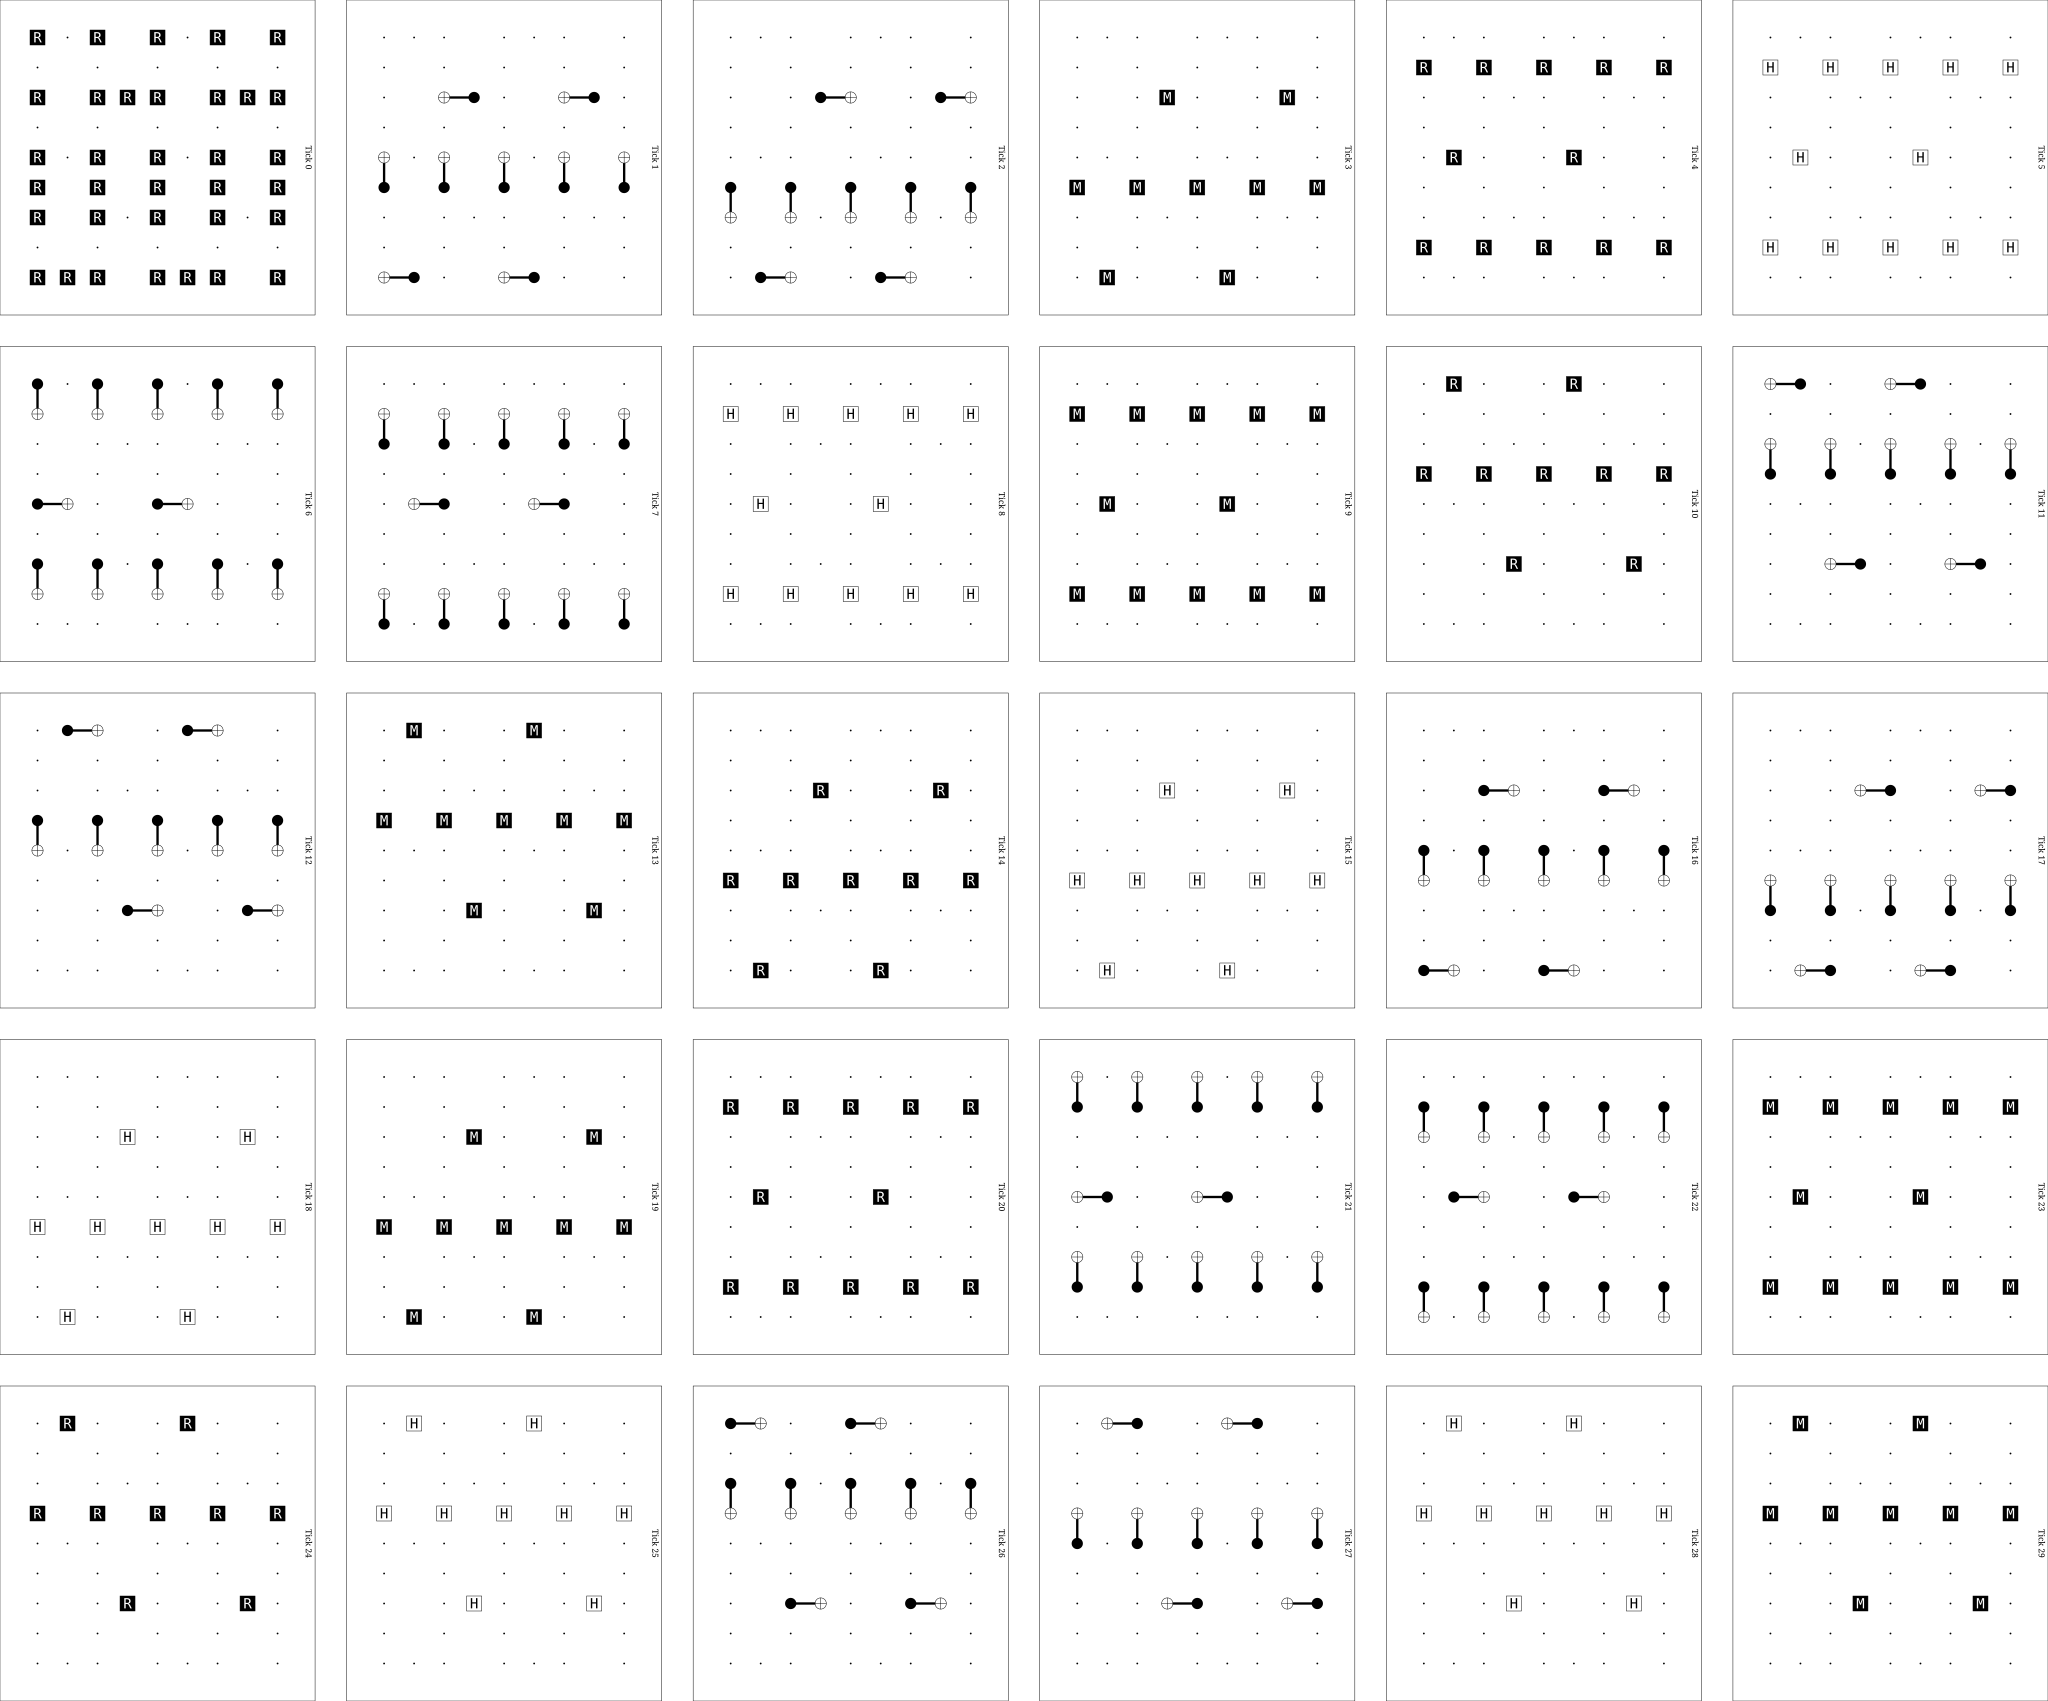

In [61]:
string = measurement_cycle(honey)
# print(string)
c_meas = stim.Circuit(string)
circuit += c_meas

circuit.diagram("timeslice-svg")

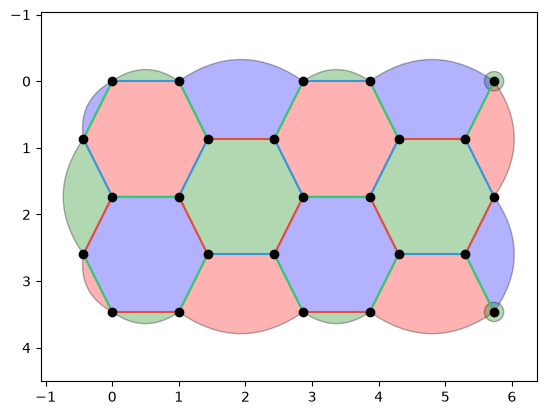

In [62]:
honey.plot_surface(coordinates='hex')